### **Jupyter Notebook de Demostración: Toolbox ML (EDA y Regresión)**

Este notebook actúa como guía interactiva y entorno de pruebas para validar todas las funciones del módulo `core.py`. Utilizaremos el dataset histórico de los pasajeros del **Titanic** (`titanic.csv`).

El objetivo es evaluar la relación de las variables del dataset con una variable **target numérica**. Para este ejercicio práctico, utilizaremos la columna **`Fare` (Tarifa pagada)** como nuestro objetivo numérico continuo.

#### Funciones a evaluar:
1. **Análisis Exploratorio Básico**: `describe_df` y `tipifica_variables`.
2. **Relación Numérica vs Numérica**: `get_features_num_regression` y `plot_features_num_regression`.
3. **Relación Categórica vs Numérica**: `get_features_cat_regression` y `plot_features_cat_regression`.

In [1]:
import os
import sys
sys.path.append(os.path.abspath("../"))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#Importamos todas las funciones públicas desde el archivo core.py local
from toolbox_ml.eda.core import (
    describe_df,
    get_features_cat_regression,
    get_features_num_regression,
    plot_features_cat_regression,
    plot_features_num_regression,
    tipifica_variables,
)

#Configuramos de estilos visuales
%matplotlib inline
sns.set_theme(style="whitegrid")

#Cargamos el dataset titanic.csv
ruta_titanic = "titanic.csv"

if os.path.exists(ruta_titanic):
    df_titanic = pd.read_csv(ruta_titanic)
    print(
        f"Dataset cargado correctamente: {df_titanic.shape[0]} filas y {df_titanic.shape[1]} columnas."
    )
else:
    print(f"Error: No se encontró el archivo '{ruta_titanic}'.")

#Visualizamos la estructura inicial del dataset
df_titanic.head()

Dataset cargado correctamente: 891 filas y 15 columnas.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


#### **Bloque 1: Resumen Descriptivo y Tipificación Automática**

Comenzaremos realizando un escaneo inicial del DataFrame con las funciones de análisis exploratorio para conocer la calidad de los datos (nulos) y su cardinalidad.

In [2]:
print("Resultado de describe_df")
resumen_estructura = describe_df(df_titanic)

#Mostramos el DataFrame
resumen_estructura

Resultado de describe_df


,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
survived,int64,0.000000,2,0.224467
pclass,int64,0.000000,3,0.336700
sex,str,0.000000,2,0.224467
age,float64,19.865320,88,9.876543
sibsp,int64,0.000000,7,0.785634
parch,int64,0.000000,7,0.785634
fare,float64,0.000000,248,27.833895
embarked,str,0.224467,3,0.336700
class,str,0.000000,3,0.336700
who,str,0.000000,3,0.336700


In [3]:
print("Sugerencia de Tipos de Variable")
#Establecemos los umbrales de decisión:
#-Menos de 4 valores únicos será categórica o binaria
#-Más de un 5% de ratio de cardinalidad se considerará una numérica continua
umbrales = {"umbral_categoria": 4, "umbral_continua": 5.0}

df_tipos = tipifica_variables(df_titanic, **umbrales)
df_tipos

Sugerencia de Tipos de Variable


,nombre_variable,tipo_sugerido
0,survived,Binaria
1,pclass,Categórica
2,sex,Binaria
3,age,Numérica Continua
4,sibsp,Numérica Discreta
5,parch,Numérica Discreta
6,fare,Numérica Continua
7,embarked,Categórica
8,class,Categórica
9,who,Categórica


#### **Bloque 2: Filtros de Regresión para Variables Numéricas**

Utilizaremos la columna **`fare`** como variable objetivo de nuestra regresión y buscaremos qué otras variables cuantitativas (como `Age`, `SibSp`, `Parch`, etc.) guardan una relación lineal estadísticamente significativa con ella mediante el coeficiente de **Pearson**.

In [4]:
target = "fare"

print(f"Buscando predictores numéricos significativos para la variable: {target}")
#Buscamos una correlación lineal absoluta mínima de 0.05 y un p-valor < 0.05
num_features_filtradas = get_features_num_regression(
    df=df_titanic, target_col=target, umbral_corr=0.05, pvalue=0.05, **umbrales
)

print(f"Variables seleccionadas por el filtro estadístico: {num_features_filtradas}")

Buscando predictores numéricos significativos para la variable: fare
Variables seleccionadas por el filtro estadístico: ['age', 'sibsp', 'parch']


Generando gráficos de dispersión para las variables numéricas...


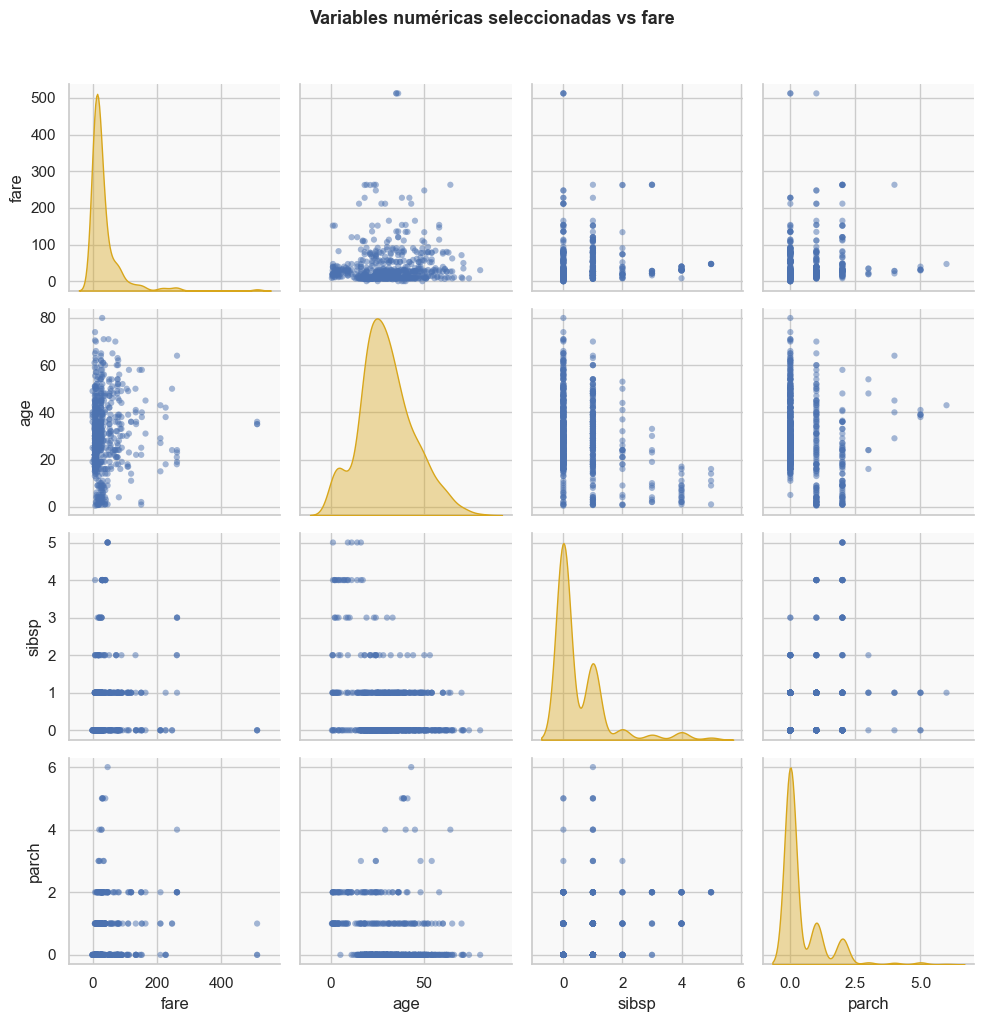

In [5]:
print("Generando gráficos de dispersión para las variables numéricas...")

#Esta función aplicará el mismo filtro matemático y pintará las distribuciones cruzadas
num_features_graficadas = plot_features_num_regression(
    df=df_titanic, target_col=target, umbral_corr=0.05, pvalue=0.05, **umbrales
)

#### **Bloque 2b: Gráficos númericos individuales**
Representamos los gráficos individualmente

Generando gráficos de dispersión para las variables numéricas...


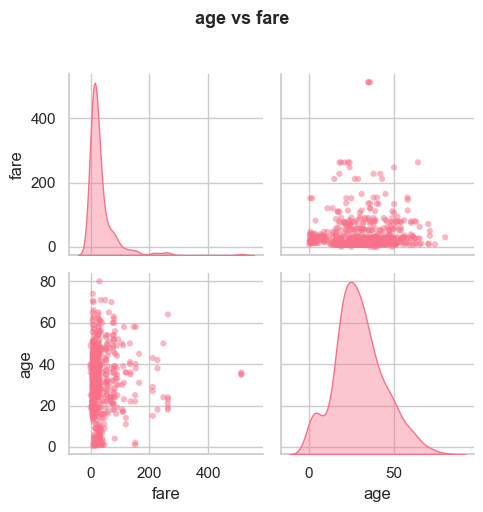

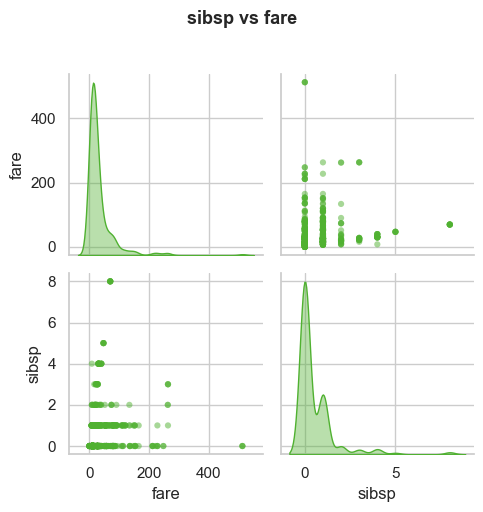

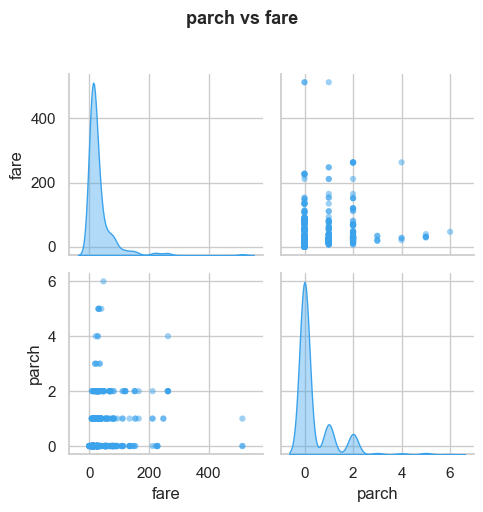

In [6]:
print("Generando gráficos de dispersión para las variables numéricas...")

#Esta función aplicará el mismo filtro matemático y pintará las distribuciones cruzadas
num_features_graficadas = plot_features_num_regression(
    df=df_titanic, target_col=target, umbral_corr=0.05, pvalue=0.05, **umbrales, with_individual_plot=True
)

#### **Bloque 2b: Efecto del umbral de correlación**

Subimos `umbral_corr` de `0.05` a `0.20` para ver cómo el filtro se vuelve más estricto y reduce el conjunto de predictores seleccionados.

In [7]:
for umbral in [0.05, 0.10, 0.15, 0.20]:
    features = get_features_num_regression(
        df=df_titanic, target_col=target, umbral_corr=umbral, pvalue=0.05, **umbrales
    )
    print(f"umbral_corr={umbral:.2f} → {features}")

umbral_corr=0.05 → ['age', 'sibsp', 'parch']
umbral_corr=0.10 → ['sibsp', 'parch']
umbral_corr=0.15 → ['sibsp', 'parch']
umbral_corr=0.20 → ['parch']


#### **Bloque 2c: Selección manual de columnas candidatas**

El parámetro `columns` permite restringir el análisis a un subconjunto de variables de interés, ignorando el resto del DataFrame.

Candidatas evaluadas: ['sibsp', 'parch', 'survived', 'pclass']
Variables seleccionadas y representadas: ['sibsp', 'parch']


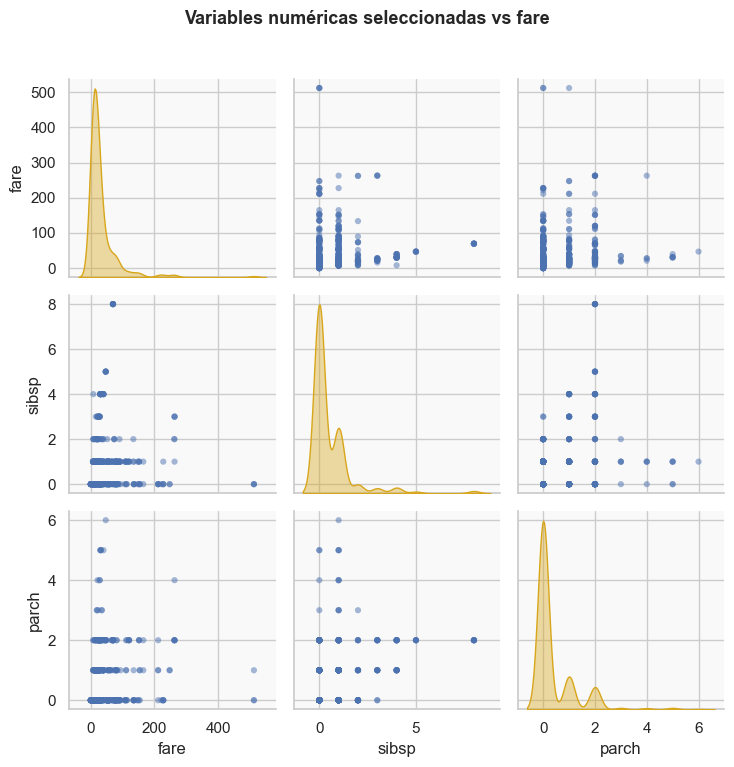

In [8]:
columnas_interes = ["sibsp", "parch", "survived", "pclass"]

print(f"Candidatas evaluadas: {columnas_interes}")
features_manual = plot_features_num_regression(
    df=df_titanic,
    target_col=target,
    columns=columnas_interes,
    umbral_corr=0.05,
    pvalue=0.05,
    **umbrales,
)
print(f"Variables seleccionadas y representadas: {features_manual}")

#### **Bloque 3: Filtros de Regresión para Variables Categóricas**

Ahora analizaremos el impacto de los factores categóricos sobre la tarifa (`fare`). 
El sistema discriminará automáticamente el test estadístico a aplicar según la cantidad de grupos de la columna:
* Si tiene 2 categorías (ej. `sex`), aplicará el test no paramétrico de **Mann-Whitney U**.
* Si tiene más de 2 categorías (ej. `pclass` o `embarked`), aplicará un **ANOVA de un factor**.

In [9]:
target = "fare"
print(
    f"Buscando predictores cualitativos estadísticamente significativos frente a '{target}'..."
)

#Buscaremos variables categóricas utilizando el estándar alpha = 0.05
cat_features_filtradas = get_features_cat_regression(
    df=df_titanic, target_col=target, pvalue=0.05
)

print(
    f"Variables categóricas que influyen en la tarifa de forma significativa: {cat_features_filtradas}"
)

Buscando predictores cualitativos estadísticamente significativos frente a 'fare'...
Variables categóricas que influyen en la tarifa de forma significativa: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


Generando histogramas solapados por grupos categóricos significativos...


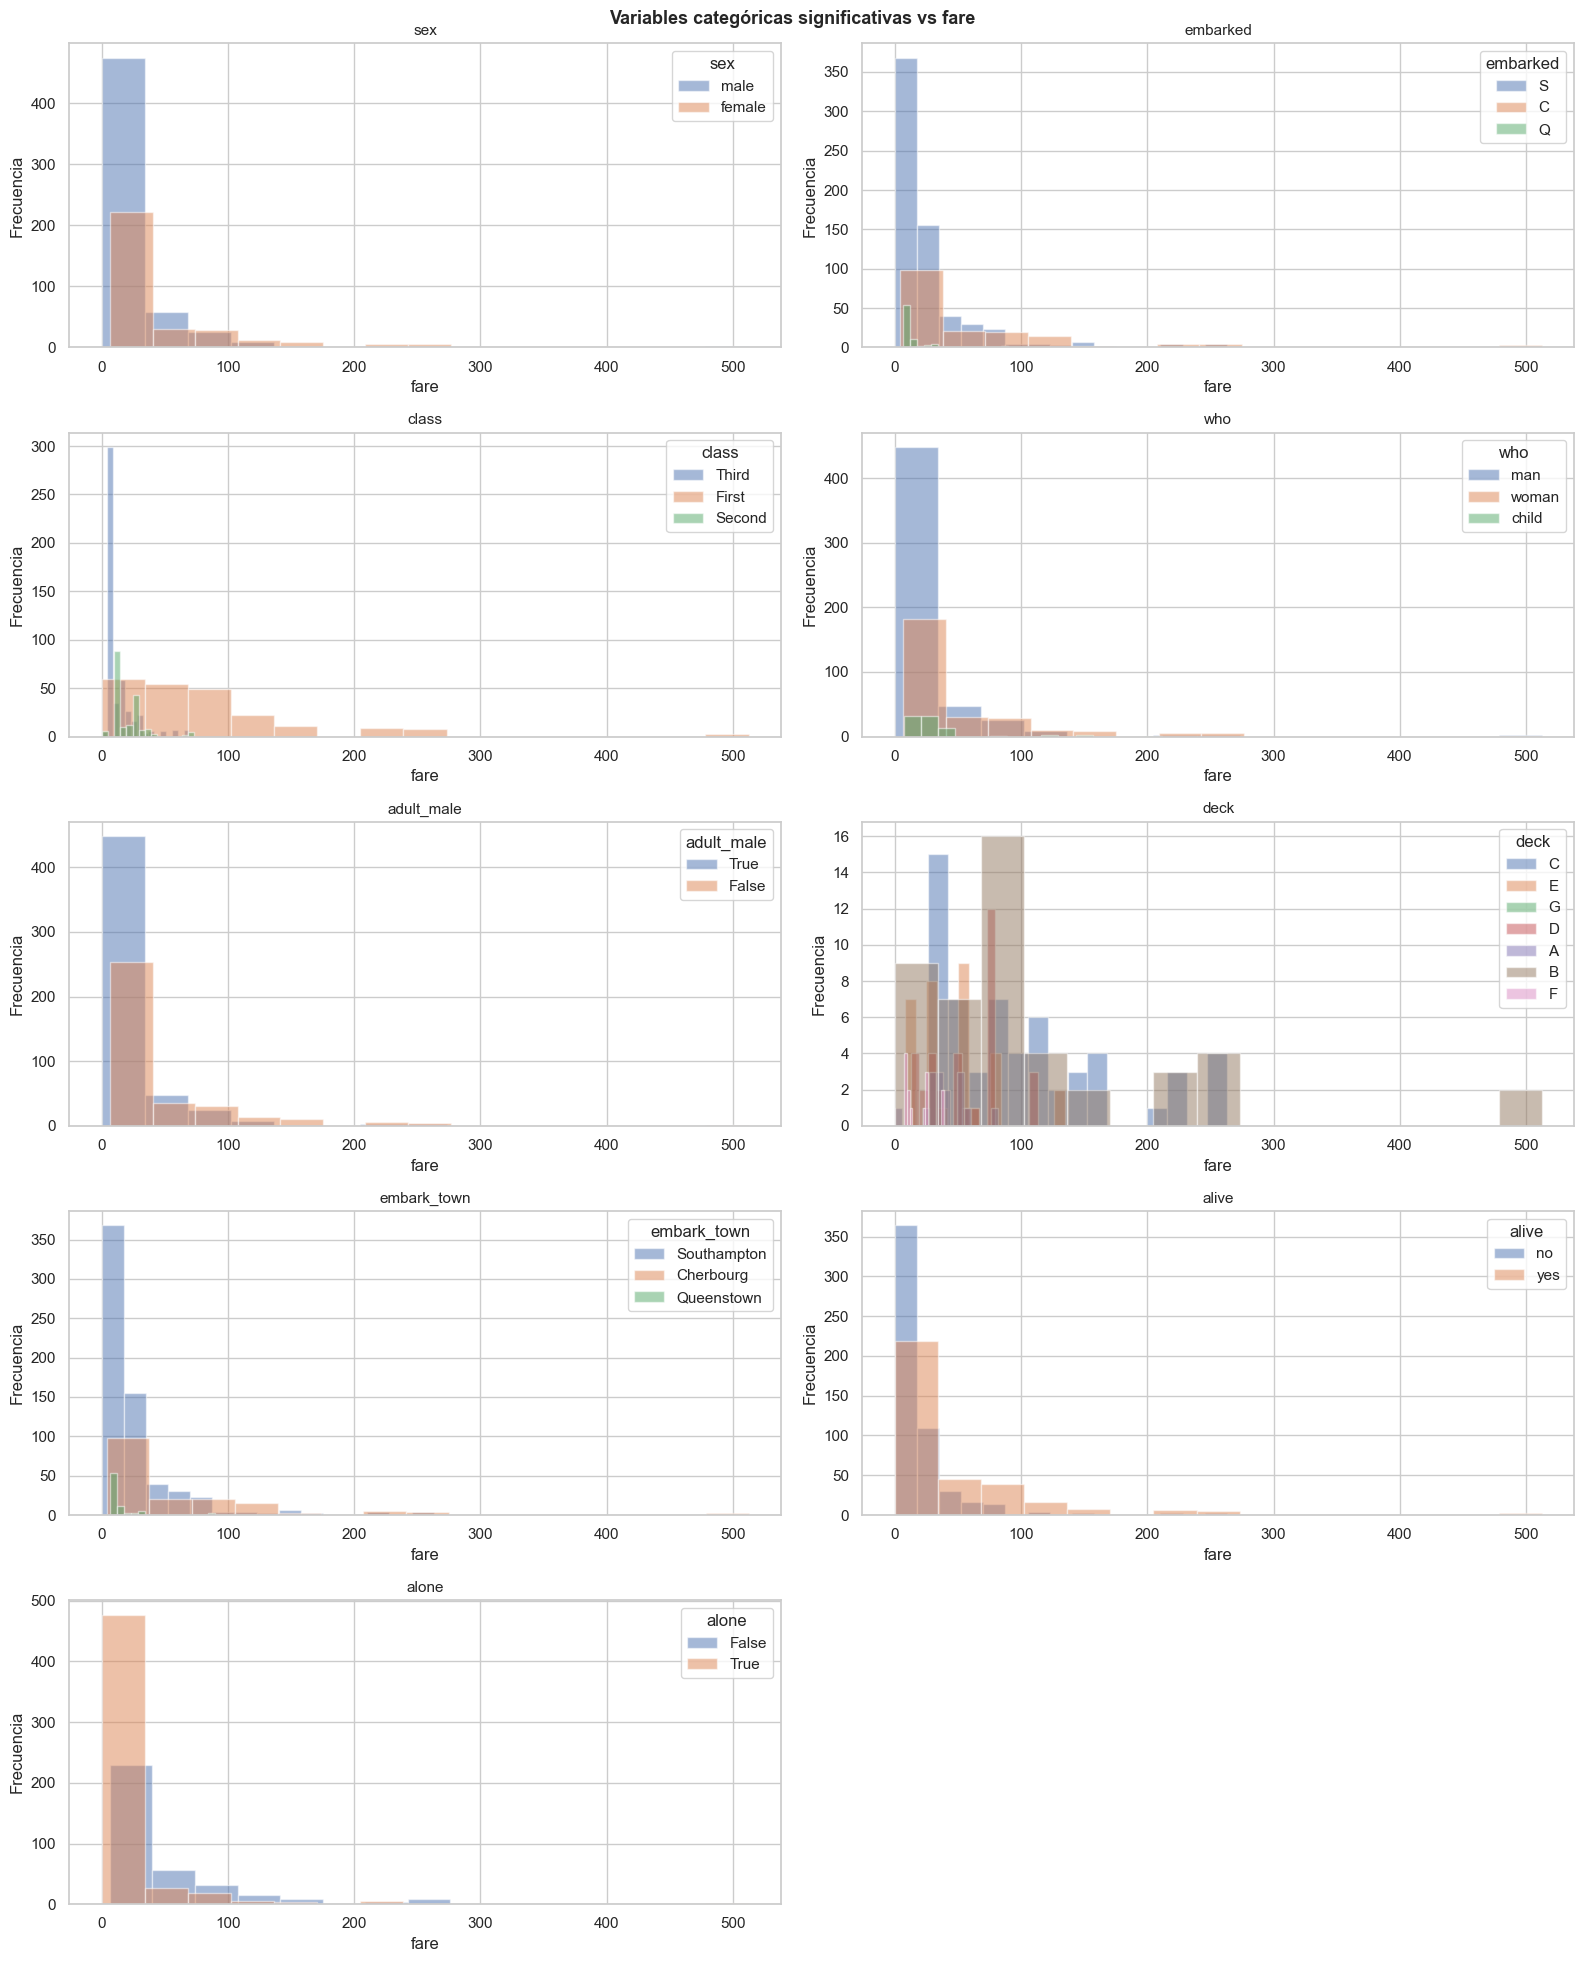

In [10]:
target = "fare"
print("Generando histogramas solapados por grupos categóricos significativos...")

#Pintamos todas las variables en un único panel con subplots para comparar las distribuciones de frecuencias
cat_features_graficadas = plot_features_cat_regression(
    df=df_titanic,
    target_col=target,
    columns=cat_features_filtradas,
    pvalue=0.05,
    with_individual_plot=False,
)

#### **Bloque 3b: Vista detallada por variable categórica**

Con `with_individual_plot=True` cada variable genera su propia figura. Útil para presentar variables clave de forma aislada. Aquí lo aplicamos sobre las tres variables más interpretables.

['class', 'sex', 'embarked']

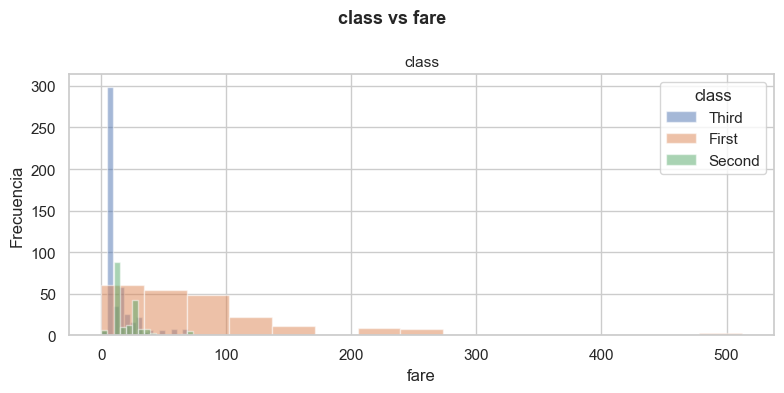

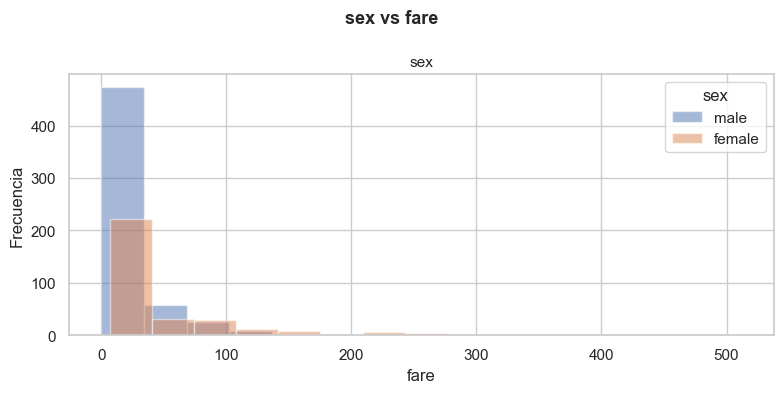

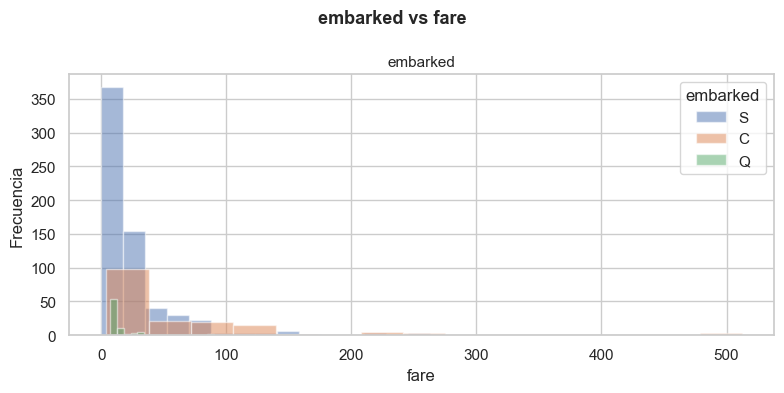

In [11]:
plot_features_cat_regression(
    df=df_titanic,
    target_col=target,
    columns=["class", "sex", "embarked"],
    pvalue=0.05,
    with_individual_plot=True,
)

---
### **Conclusiones**

| Función | Variables seleccionadas sobre `fare` |
|---|---|
| `get_features_num_regression` (corr ≥ 0.05) | `age`, `sibsp`, `parch` |
| `get_features_cat_regression` (p < 0.05) | `sex`, `embarked`, `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone` |

**Observaciones clave:**
- La tarifa (`fare`) apenas correlaciona con variables numéricas: las relaciones lineales son débiles, lo que sugiere que el precio depende más del tipo de billete (categórica `class`) que de características personales continuas. Subir `umbral_corr` de `0.05` a `0.20` elimina todos los predictores numéricos, lo que confirma que las correlaciones son modestas.
- Entre las variables categóricas, `class` es la más informativa: la distribución de `fare` varía drásticamente entre Primera, Segunda y Tercera clase.